In [3]:
from scripts.AbstractExperiments import ExperimentRunner, GenerateConfigs
from EnvironmentBuilder.SearchRescue.Rescue import Rescue
import EnvironmentBuilder.SearchRescue.Drawing as SearchRescueDraw
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"

In [26]:
def GenerateTeamConfigs(teams_:list, name_prefix=None):
    configs = {}
    if name_prefix is None:
        name_prefix = f"{len(teams_)}_"
    # Act-Utilitarianism
    con = {"Theories": [["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", "Add_Util"])
    configs[f"{name_prefix}add"] = con

    # Balance
    con = {"Theories": [], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", f"{t}"])
    configs[f"{name_prefix}bal"] = con

    # Fairness
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair"]])
    configs[f"{name_prefix}fair"] = con

    # Fairness + Others
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    #configs[f"{name_prefix}fair_bal"] = con

    # Fairness + Act-Utilitarianism
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    #configs[f"{len(teams_)}_fair_bal"] = con

    # Rawls
    con = {"Theories":[["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls"]])
    configs[f"{name_prefix}rawl"] = con

    # Rawls + Others
    con = {"Theories": [["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Rawls"]])
    #configs[f"{name_prefix}rawl_bal"] = con

    return configs

def MakeTeamWeights(teams_):
    p = [2**i for i in range(0, len(teams_))]
    total = sum(p)
    w = [i / total for i in p]
    o = {}
    for t in teams_:
        for i, t in enumerate(teams_):
            o[f"{t}_hosp_success"] = w[i]
    return o

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "^",
    "Rawls": "*"
}
colours = {
    "Separate Theories": "green",
    "Act-Utilitarianism": "blue",
    "Fairness": "orange",
    "Rawls": "red"
}

print(MakeTeamWeights([i for i in range(3)]))


{'0_hosp_success': 0.14285714285714285, '1_hosp_success': 0.2857142857142857, '2_hosp_success': 0.5714285714285714}


In [13]:
configs = []
env_reps = 1
for horizon_ in range(3,7):
    for Comms in range(2,7):
        teams = [f"{i}" for i in range(Comms)]
        odds = MakeTeamWeights(teams)
        configs += GenerateConfigs(inputConfigs=GenerateTeamConfigs(teams, name_prefix=f"{len(teams)}_h{horizon_}"), 
            defaultConfig={"Horizon": horizon_, "Teams":teams, "unknown_depth": 0, "Odds":odds})

er = ExperimentRunner("Rescue", configs, MoralPlanner_Location="/../")
er.buildEnvironments()
er.run(envRepetitions=env_reps)

Written Rescue MMMDP with 13 states and theories [{'Name': 'Add_Util', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-10_14:32:29/mdps/2_h3add_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': '0', 'Type': 'Utility', 'Rank': 0}, {'Name': '1', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-10_14:32:29/mdps/2_h3bal_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-10_14:32:29/mdps/2_h3fair_con0.json

Written Rescue MMMDP with 13 states and theories [{'Name': 'Rawls', 'Type': 'Maximin', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/../Data/Experiments/Rescue/2026-07-10_14:32:29/mdps/2_h3rawl_con0.json

Written Rescue MMMDP with 18 states and theories [{'Name':

In [14]:
df = pd.DataFrame(er.data)
df = df.drop(labels=['Conf_rep', 'Theories', 'Considerations', 'CQ1_time', 'CQ2_time', 'Out_time', 'Sol_reduce_time'], axis=1)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
df['communities'] = df['Config_name'].str[:1]
df["Config_name"] = np.select(
    [
        df["Config_name"].str.contains("fair_bal", case=False, na=False),
        df["Config_name"].str.contains("rawls_bal", case=False, na=False),
        df["Config_name"].str.contains("add", case=False, na=False),
        df["Config_name"].str.contains("bal", case=False, na=False),
        df["Config_name"].str.contains("fair", case=False, na=False),
        df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + balance",
        "Rawls + balance",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=df["Config_name"]
)
df.head(500)

,Config_name,Env_rep,Total_time,Heuristic_time,Plan_time,Sol_time,Mehr_time,Expanded_states,BSG_states,Average_histories,...,Num_of_sols,Total_Attacks,Total_reachable_policies,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities
0,Act-Utilitarianism,0,86,6,27,52,1,11,13,3,...,2,2,12,0,1.3333,NaN,NaN,NaN,NaN,2
1,Separate Theories,0,65,6,19,39,1,11,13,3,...,2,6,12,0.6667,0,NaN,NaN,NaN,NaN,2
2,Fairness,0,50,4,15,30,1,11,13,3,...,2,2,12,0.6667,0,NaN,NaN,NaN,NaN,2
3,Rawls,0,64,5,19,39,1,11,13,3,...,2,0,12,0.6667,0,NaN,NaN,NaN,NaN,2
4,Act-Utilitarianism,0,98,9,31,57,1,16,18,3,...,3,4,21,0,0,1.1429,NaN,NaN,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Rawls,0,3426745,52,126033,387819,2912841,59,61,7,...,3523,0,346613655,0.0645,0.0624,0.0001,0,0.0161,NaN,5
76,Act-Utilitarianism,0,5910618,78,435098,2124325,3351117,70,72,7,...,8820,62142,953168928,0,0,0,0,0,2.5397,6
77,Separate Theories,0,15802595,79,432112,2139941,13230463,70,72,7,...,8820,378797,953168928,0,0,0,0,1.2698,0,6
78,Fairness,0,21452087,88,438414,2151692,18861893,70,72,7,...,8820,54511,953168928,0.0315,0.0307,0,0,0.0081,0.0079,6


findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: F

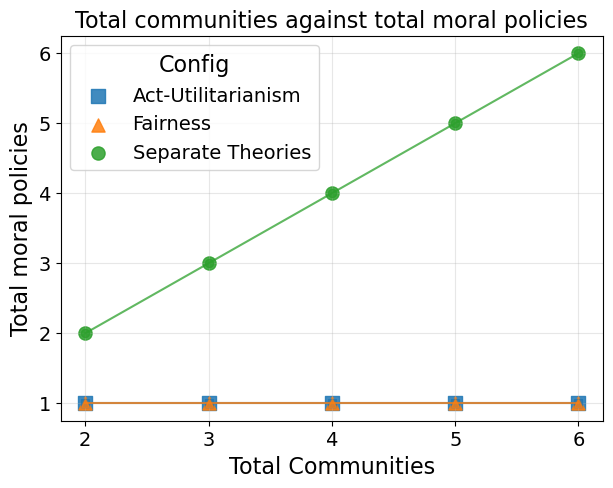

In [28]:
plot_df = df.reset_index().copy()
configs = ["Separate Theories", "Act-Utilitarianism", "Fairness"]
plot_df = plot_df[plot_df["Config_name"].isin(configs)]

# Make sure communities is numeric
plot_df["communities"] = pd.to_numeric(plot_df["communities"], errors="coerce")
plot_df["Num_of_min_non_accept"] = pd.to_numeric(
    plot_df["Num_of_min_non_accept"],
    errors="coerce"
)

# Drop rows where conversion failed
plot_df = plot_df.dropna(subset=["communities", "Num_of_min_non_accept"])

avg_df = (
    plot_df
    .groupby(["Config_name", "communities"], as_index=False)["Num_of_min_non_accept"]
    .mean()
    .sort_values(["Config_name", "communities"])
)

fig, ax = plt.subplots(figsize=(7, 5))



for config, group in avg_df.groupby("Config_name", sort=False):
    x = group["communities"].astype(float)

    ax.scatter(
        x=x,
        y=group["Num_of_min_non_accept"],
        s=90,
        alpha=0.85,
        marker=markers.get(config, "o"),
        label=config
    )

    ax.plot(
        x,
        group["Num_of_min_non_accept"],
        alpha=0.75,
        marker=markers.get(config, "o")
    )

ax.set_xlabel("Total Communities")
ax.set_ylabel("Total moral policies")
ax.set_title("Total communities against total moral policies")

ax.set_xticks(sorted(avg_df["communities"].unique()))

ax.grid(True, alpha=0.3)
ax.legend(title="Config", loc='upper left')

plt.show()

findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: Font family 'Charter' not found.
findfont: F

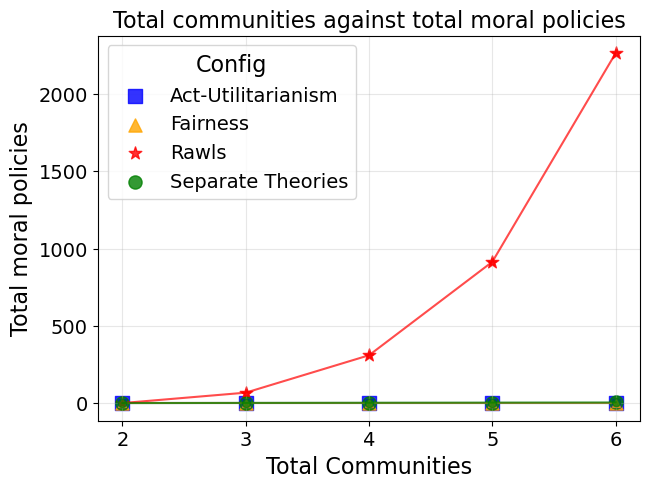

In [27]:
plot_df = df.reset_index().copy()

# Keep both configurations
plot_df = plot_df[plot_df["Config_name"].isin(["Separate Theories", "Act-Utilitarianism", "Fairness", "Rawls"])]

# Average Num_of_min_non_accept for each Config_name and number of communities
avg_df = (
    plot_df
    .groupby(["Config_name", "communities"], as_index=False)["Num_of_min_non_accept"]
    .mean()
    .sort_values(["Config_name", "communities"])
)

fig, ax = plt.subplots(figsize=(7, 5))

for config, group in avg_df.groupby("Config_name"):
    ax.scatter(
        x=group["communities"],
        y=group["Num_of_min_non_accept"],
        s=90,
        alpha=0.8,
        label=config,
        marker=markers.get(config, "o"),
        c=colours[config]
    )

    ax.plot(
        group["communities"],
        group["Num_of_min_non_accept"],
        alpha=0.7,
        marker=markers.get(config, "o"),
        c=colours[config]

    )

ax.set_xlabel("Total Communities")
ax.set_ylabel("Total moral policies")
ax.set_title("Total communities against total moral policies")

ax.grid(True, alpha=0.3)
ax.legend(title="Config")

plt.show()

In [17]:
cols = [f"{t}:wellbeing" for t in teams]
worth_df = pd.DataFrame(er.GetWorthData(worth_tags=[f"{t}:wellbeing" for t in teams], envRepetitions=env_reps))
worth_df = worth_df.drop(columns=["Conf_rep"])
worth_df['communities'] = worth_df['Config_name'].str[:1]
worth_df["Config_name"] = np.select(
    [
        worth_df["Config_name"].str.contains("fair_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("rawls_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("add", case=False, na=False),
        worth_df["Config_name"].str.contains("bal", case=False, na=False),
        worth_df["Config_name"].str.contains("fair", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + Separate",
        "Rawls + Separate",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=worth_df["Config_name"]
)
worth_df = worth_df.groupby(['Config_name', 'Env_rep', 'communities', 'Horizon'], sort=False, as_index=False)
worth_df.head(1000)

,Config_name,Env_rep,Horizon,Moral_policy_idx,Non-acceptability,0:wellbeing,1:wellbeing,2:wellbeing,3:wellbeing,4:wellbeing,5:wellbeing,communities
0,Act-Utilitarianism,0,4,0,0.0,0,1.3333,NaN,NaN,NaN,NaN,2
1,Separate Theories,0,4,0,1.0,0.6667,0,NaN,NaN,NaN,NaN,2
2,Separate Theories,0,4,1,1.0,0,1.3333,NaN,NaN,NaN,NaN,2
3,Fairness,0,4,0,0.0,0.6667,0,NaN,NaN,NaN,NaN,2
4,Rawls,0,4,0,0.0,0.6667,0,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
6529,Rawls,0,7,995,0.0,0,0.0322,0.0154,0,0.0635,0.7579,6
6530,Rawls,0,7,996,0.0,0,0.0035,0,0.254,0.1936,0.0645,6
6531,Rawls,0,7,997,0.0,0.0018,0.0005,0.007,0.5443,0,0,6
6532,Rawls,0,7,998,0.0,0.003,0.006,0.0041,0,0.5079,0.2827,6
